## Objetivos.

Los objetivos principales de este análisis del dataset de ventas E-commerce (data.csv) son los siguientes: 

- Generar una predicción de ventas desde el día 9 de noviembre de 2011 hasta el día 9 de diciembre de 2011 y comprobar los resultados obtenidos. Los datos de entrenamiento irán desde el día 1 de diciembre de 2010 hasta el día 8 de noviembre de 2011.

- Clasificar a los clientes en función de sus características y comportamientos de compra, utilizando técnicas de clustering para identificar segmentos de clientes con patrones similares.

Para ello realizaremos una exploración inicial de los datos, identificando su estructura y valores faltantes o erróneos. 
Posteriormente trataremos los datos para que queden limpios y puedan realizarse las próximas fases de manera efectiva. 
Tras realizar la limpieza completa, generaremos nuevas variables dependiendo del modelo a entrenar, ya sea regresión o clustering.
Finalmente, se entrenarán los modelos de regresión y clustering, evaluando su rendimiento.

#### Librerías utilizadas.

In [71]:
import pandas as pd
import matplotlib.pyplot as plt

#### Funciones auxiliares.

In [72]:
def obtener_n_filas_duplicadas(df: pd.DataFrame) -> int:
  return df.duplicated().sum()

def obtener_n_filas_con_nulos(df: pd.DataFrame) -> int:
  return df[df.isnull().any(axis=1)].shape[0]

def obtener_n_filas_con_nulos_por_columna(columna: str, df: pd.DataFrame) -> int:
  return df[columna].isnull().sum()

def obtener_n_valores_negativos_por_columna(columna: str, df: pd.DataFrame) -> int:
  return (df[columna] < 0).sum()

def obtener_n_valores_cero_por_columna(columna: str, df: pd.DataFrame) -> int:
  return (df[columna] == 0).sum()

def obtener_n_valores_unicos_por_columna(columna: str, df: pd.DataFrame) -> int:
  return df[columna].nunique()

## Exploración inicial

#### Carga del csv.

Como daba error al cargar el csv por caracteres incompatibles, hemos forzado
la codificación del csv a "ISO-8859-1". Ahora no da error al cargarlo, pero es posible que haya caracteres mal interpretados.

In [73]:
df = pd.read_csv('../data/data.csv', encoding='ISO-8859-1')

#### Filas, columnas y tipos de datos.

Aquí visualizamos el tamaño del dataset en filas y columnas. Tenemos que "Quantity", "UnitPrice" y "CustomerID" están en formato numérico. Tanto "InvoiceNo" como "StockCode" y "CustomerID" son los identificadores únicos de este dataset.

- InvoiceNo:  Identificador único de cada factura.

- StockCode:  Identificador único de cada producto.

- Description:  Descripción del producto.

- Quantity:  Cantidad de cada producto por factura.

- InvoiceDate:  Fecha de la factura.

- UnitPrice:  Precio unitario de cada producto.

- CustomerID:  Identificador único de cada cliente.

- Country:  País del cliente.

In [74]:
filas_totales = len(df)
columnas_totales = len(df.columns)

print(f"Número de filas: {filas_totales}")
print(f"Número de columnas: {columnas_totales}")

df.dtypes

Número de filas: 541909
Número de columnas: 8


InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

#### Visualización de las primeras filas.

Visualizamos las primeras filas del dataset y comprobamos que InvoiceDate es una variable relacionada con las fechas representada en formato string.
Habría que convertirla a formato fecha para poder trabajar con ella posteriormente. Los formatos que buscaremos para cada variable son los siguientes:

- InvoiceNo:  String.

- StockCode:  String.

- Description:  String.

- Quantity:  Numérico.

- InvoiceDate:  Fecha.

- UnitPrice:  Numérico.

- CustomerID:  String.

- Country:  String.

Por lo tanto quedan como datos categóricos: 

- InvoiceNo. 
- StockCode. 
- Description. 
- CustomerID. 
- Country. 

Como datos numéricos quedan:

- Quantity.
- UnitPrice.

Como dato de tipo fecha queda:

- InvoiceDate.

In [75]:
df.head(n=5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


#### Valores duplicados.

Las filas duplicadas no aportan ningún valor a nuestro análisis, más bien al contrario produciendo sesgos en el modelo
al repetir la misma información y aumentar el peso de ciertos datos. 
Solamente representan el 1% del total de filas, por lo que no afectará negativamente a la muestra.

Cantidad de filas duplicadas: 5268
Porcentaje de filas duplicadas: 0.97%
Porcentaje de filas no duplicadas: 99.03%


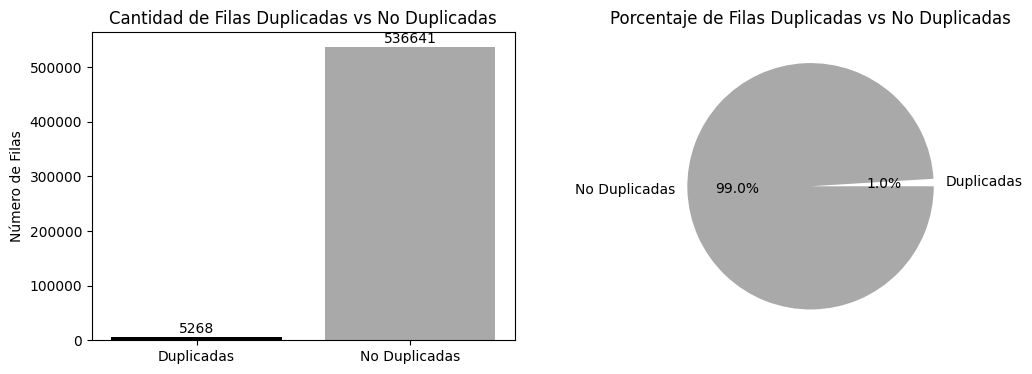

In [76]:
filas_duplicadas = df.duplicated().sum()

print(f"Cantidad de filas duplicadas: {filas_duplicadas}")
print(f"Porcentaje de filas duplicadas: {filas_duplicadas / filas_totales * 100:.2f}%")
print(f"Porcentaje de filas no duplicadas: {(filas_totales - filas_duplicadas) / filas_totales * 100:.2f}%")

valores = [filas_duplicadas, filas_totales - filas_duplicadas]
etiquetas = ['Duplicadas', 'No Duplicadas']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bars = axes[0].bar(etiquetas, valores, color=['black', 'darkgray'])
axes[0].bar(etiquetas, valores, color=['black', 'darkgray'])
axes[0].set_title('Cantidad de Filas Duplicadas vs No Duplicadas')
axes[0].bar_label(bars, padding=1)
axes[0].set_ylabel('Número de Filas')
axes[1].pie(valores, labels=etiquetas, autopct='%1.1f%%', colors=['white', 'darkgray'])
axes[1].set_title('Porcentaje de Filas Duplicadas vs No Duplicadas')
plt.show()

#### Valores nulos.

Da un total de 1454 valores nulos para la descripción y 135080 valores nulos para el CustomerID. Posiblemente se deba a falta de registro en los clientes 
y descripciones sin asignar. Más adelante veremos si se puede recuperar de alguna forma o deberán ser eliminados.

Cantidad de filas con nulos en la columna 'InvoiceNo': 0
Cantidad de filas con nulos en la columna 'StockCode': 0
Cantidad de filas con nulos en la columna 'Description': 1454
Cantidad de filas con nulos en la columna 'Quantity': 0
Cantidad de filas con nulos en la columna 'InvoiceDate': 0
Cantidad de filas con nulos en la columna 'UnitPrice': 0
Cantidad de filas con nulos en la columna 'CustomerID': 135080
Cantidad de filas con nulos en la columna 'Country': 0


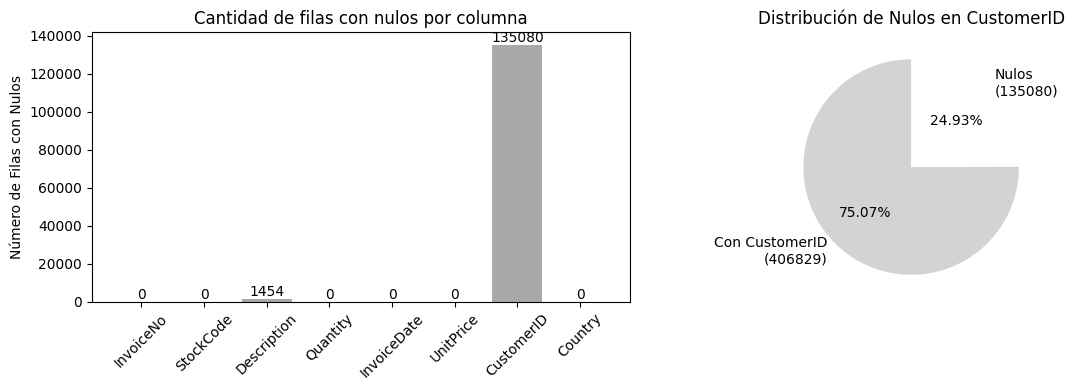

In [77]:
for columna in df.columns:  
  print(f"Cantidad de filas con nulos en la columna '{columna}': {obtener_n_filas_con_nulos_por_columna(columna, df)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
nulos_por_columna = [obtener_n_filas_con_nulos_por_columna(columna, df) for columna in df.columns]
axes[0].bar(df.columns, nulos_por_columna, color='darkgray')
axes[0].set_title('Cantidad de filas con nulos por columna')
axes[0].set_ylabel('Número de Filas con Nulos')
axes[0].bar_label(axes[0].containers[0], padding=0)
axes[0].tick_params(axis='x', rotation=45)

nulos_customerid = obtener_n_filas_con_nulos_por_columna('CustomerID', df)
con_customerid = filas_totales - nulos_customerid

valores = [con_customerid, nulos_customerid]
etiquetas = [f'Con CustomerID\n({con_customerid})', f'Nulos\n({nulos_customerid})']

axes[1].pie(valores, labels=etiquetas, autopct='%1.2f%%', startangle=90, colors=['lightgray', 'white'])
axes[1].set_title('Distribución de Nulos en CustomerID')
plt.tight_layout()
plt.show()

#### Valores únicos.

Ahora visualizamos la cantidad de valores únicos que hay en cada variable y respecto al total. Podemos observar lo siguiente:

- Muchas filas van a pertenecer al mismo InvoceNo. Lo que signfica que dentro de una misma factura hay varios productos.

- La cantidad de valores únicos en StockCode no coincide con la cantidad de valores en Description. De hecho hay más valores únicos en Description que en StockCode, por lo que da a entender que algunas descripciones se asignaron erróneamente.

- 722 valores en Quantity indican la presencia de valores muy dispares, lo que puede ser un indicativo de outliers o valores erróneos.

- Hay menos UnitPrice que StockCode por lo que existirán productos con el mismo precio.

- Hay menos InvoiceDate que InvoiceNo. Puede ser que hayan fechas repetidas o que existan facturas con fecha vacía.

- Hay un total de 38 países, por lo tanto la empresa es internacional.

In [78]:
for columns in df.columns:
  unicos = obtener_n_valores_unicos_por_columna(columns, df)
  print(f"Número de valores únicos en {columns}: {unicos} | Totales: {filas_totales}")

Número de valores únicos en InvoiceNo: 25900 | Totales: 541909
Número de valores únicos en StockCode: 4070 | Totales: 541909
Número de valores únicos en Description: 4223 | Totales: 541909
Número de valores únicos en Quantity: 722 | Totales: 541909
Número de valores únicos en InvoiceDate: 23260 | Totales: 541909
Número de valores únicos en UnitPrice: 1630 | Totales: 541909
Número de valores únicos en CustomerID: 4372 | Totales: 541909
Número de valores únicos en Country: 38 | Totales: 541909


#### Análisis de las variables numéricas.

Aquí podemos observar que existen valores negativos en variable de Quantity y de Unit Price. CustomerID es tratado como numérico por defecto, pero es un identificador de cliente y no debe analizarse como tal. Aún así, sirve para observar que todos los identificadores de cliente son numéricos y que no tienen valores negativos.

In [79]:
df_numerico = df.select_dtypes(include=['number'])
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


#### Análisis de las variables categóricas y texto.

Un pequeño desglose de las variables categóricas. Nos da una idea para calcular los valores más frecuentes en cada variable categórica. 

In [80]:
df_texto = df.select_dtypes(include=['string'])
df_texto.describe()

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


De los valores más frecuentes y menos frecuentes en cada variable podemos sacar conclusiones.

- Existen facturas con un gran cantidade apariciones, lo que indica que fueron grandes compras con muchos productos diferentes, posiblemente de grandes clientes o empresas. Distan mucho de otras que solamente aparecen una vez.

- Hay productos (StockCode) que se venden mucho más que otros, lo que indica que hay una gran demanda. Otros productos de venden muy poco, veremos si se pueden tratar de errores o si realmente son productos con poca demanda.

- Como hemos dicho anteriormente, hay top descripciones que no coinciden con el número de top productos. Además por la parte baja existen descripciones con un valor extraño, posiblemente debido a errores de registro, sucesos aislados o a descripciones sin asignar.

- Reino Unido es con diferencia el país con más operaciones de compra con mucha diferencia del segundo.

In [81]:
for column in df_texto.columns:
  mas_frecuentes = df_texto[column].value_counts().head(5)
  menos_frecuentes = df_texto[column].value_counts().tail(5)
  print(f"Conteo de los 5 valores más frecuentes en {column}:\n\n{mas_frecuentes}\n")
  print(f"Conteo de los 5 valores menos frecuentes en {column}:\n\n{menos_frecuentes}\n")
  print("-----------------------------\n")

Conteo de los 5 valores más frecuentes en InvoiceNo:

InvoiceNo
573585    1114
581219     749
581492     731
580729     721
558475     705
Name: count, dtype: int64

Conteo de los 5 valores menos frecuentes en InvoiceNo:

InvoiceNo
581487     1
581491     1
C581499    1
581566     1
C581568    1
Name: count, dtype: int64

-----------------------------

Conteo de los 5 valores más frecuentes en StockCode:

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
Name: count, dtype: int64

Conteo de los 5 valores menos frecuentes en StockCode:

StockCode
23609     1
85179a    1
23617     1
90214U    1
47591b    1
Name: count, dtype: int64

-----------------------------

Conteo de los 5 valores más frecuentes en Description:

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
Name: count,

#### Análisis InvoiceNo.

  Aquí observamos patrones en InvoiceNo para detectar posibles anomalías. Vemos que hay dos posibilidades, que tenga 6 caracteres o que tenga 7 caracteres. Vemos que en todos los casos con 7 caracteres aparece que los identificadores no son completamente numéricos. Con un head() podemos ver el formato común de los StockCodes además de comprobar que tienen cantidades negativas y algún StockCode o descripción extraños. 

In [82]:
longitudes_invoiceNo = df['InvoiceNo'].str.len().value_counts().sort_index()
print(f"\nDistribución de longitudes:\n{longitudes_invoiceNo}")

invoiceNo_no_numericos = df[~df['InvoiceNo'].str.match(r'^\d+$')]
print(f"InvoiceNo con caracteres no numéricos: {len(invoiceNo_no_numericos)}")

invoiceNo_no_numericos_6 = invoiceNo_no_numericos[invoiceNo_no_numericos['InvoiceNo'].str.len() == 6]
print(f"InvoiceNo con caracteres no numéricos y longitud 6: {len(invoiceNo_no_numericos_6)}")

invoiceNo_no_numericos_7 = invoiceNo_no_numericos[invoiceNo_no_numericos['InvoiceNo'].str.len() == 7]
print(f"InvoiceNo con caracteres no numéricos y longitud 7: {len(invoiceNo_no_numericos_7)}\n")

invoiceNo_no_numericos.head(11)


Distribución de longitudes:
InvoiceNo
6    532618
7      9291
Name: count, dtype: int64
InvoiceNo con caracteres no numéricos: 9291
InvoiceNo con caracteres no numéricos y longitud 6: 0
InvoiceNo con caracteres no numéricos y longitud 7: 9291



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,12/1/2010 12:38,4.25,17897.0,United Kingdom


Gracias al head() vemos que todos los InvoiceNo con 7 caracteres empiezan por la letra "C", lo que indica que son facturas canceladas. Revisando mejor los patrones, encontramos que siempre se sigue el mismo formato, pero en 3 ocasiones empieza por la letra A. 

In [83]:
patron_letra_numeros = r'^[A-Za-z]\d{6}$'
cumple_patron = invoiceNo_no_numericos_7[invoiceNo_no_numericos_7['InvoiceNo'].str.match(patron_letra_numeros)]
print(f"InvoiceNo de 7 caracteres con formato letra + 6 números: {len(cumple_patron)} / {len(invoiceNo_no_numericos_7)}")

letras_iniciales = invoiceNo_no_numericos_7['InvoiceNo'].str[0].value_counts().sort_index()
print(f"\nLetras únicas por las que empiezan: {letras_iniciales.index.tolist()}")
print(f"\nConteo de InvoiceNo por letra inicial:")
print(letras_iniciales)

InvoiceNo de 7 caracteres con formato letra + 6 números: 9291 / 9291

Letras únicas por las que empiezan: ['A', 'C']

Conteo de InvoiceNo por letra inicial:
InvoiceNo
A       3
C    9288
Name: count, dtype: int64


Aquí se puede apreciar que la mayoría absoluta de los valores con InvoiceNo no numéricos tienen cantidades negativas en Quantity, sólo 3 valores llegan a ser positivos. Esto puede ser un indicativo de que se tratan de devoluciones, cancelaciones o incluso errores.

In [84]:
invoiceNo_no_numericos_7_quantity_negativa = invoiceNo_no_numericos_7[invoiceNo_no_numericos_7['Quantity'] < 0]
invoiceNo_no_numericos_7_quantity_cero = invoiceNo_no_numericos_7[invoiceNo_no_numericos_7['Quantity'] == 0]
invoiceNo_no_numericos_7_quantity_positiva = invoiceNo_no_numericos_7[invoiceNo_no_numericos_7['Quantity'] > 0]
negativos_quantity = invoiceNo_no_numericos_7_quantity_negativa['Quantity'].count()
cero_quantity = invoiceNo_no_numericos_7_quantity_cero['Quantity'].count()
positivos_quantity = invoiceNo_no_numericos_7_quantity_positiva['Quantity'].count()
print(f"Cantidad total de valores negativos en Quantity para InvoiceNo no numéricos con longitud 7: {negativos_quantity}")
print(f"Cantidad total de valores cero en Quantity para InvoiceNo no numéricos con longitud 7: {cero_quantity}")
print(f"Cantidad total de valores positivos en Quantity para InvoiceNo no numéricos con longitud 7: {positivos_quantity}")

Cantidad total de valores negativos en Quantity para InvoiceNo no numéricos con longitud 7: 9288
Cantidad total de valores cero en Quantity para InvoiceNo no numéricos con longitud 7: 0
Cantidad total de valores positivos en Quantity para InvoiceNo no numéricos con longitud 7: 3


Las 3 filas que quedan con cantidades positivas carecen de CustomerID y dos tienen precio unitario negativo. Además la descripción muestra que se trata de un mal cobro en todos los casos. Vemos que encaja exactamente con los 3 casos de InvoiceNo que empiezan por la letra A.

In [85]:
invoiceNo_no_numericos_7_quantity_positiva.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,8/12/2011 14:50,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


Con el esquema general de InvoiceNo, determinamos que los valores con 7 caracteres serán eliminados en el tratamiento del dataset.

#### Análisis StockCode.

Para los StockCode tenemos unas longitudes muy dispares. Pero la mayoría de datos se agrupan en 5 caracteres, seguidos de 6. El resto representan una cantidad muy pequeña.


Distribución de longitudes:
StockCode
1        715
2        144
3        710
4       1276
5     487036
6      51488
7        390
8         31
9         48
12        71
Name: count, dtype: int64


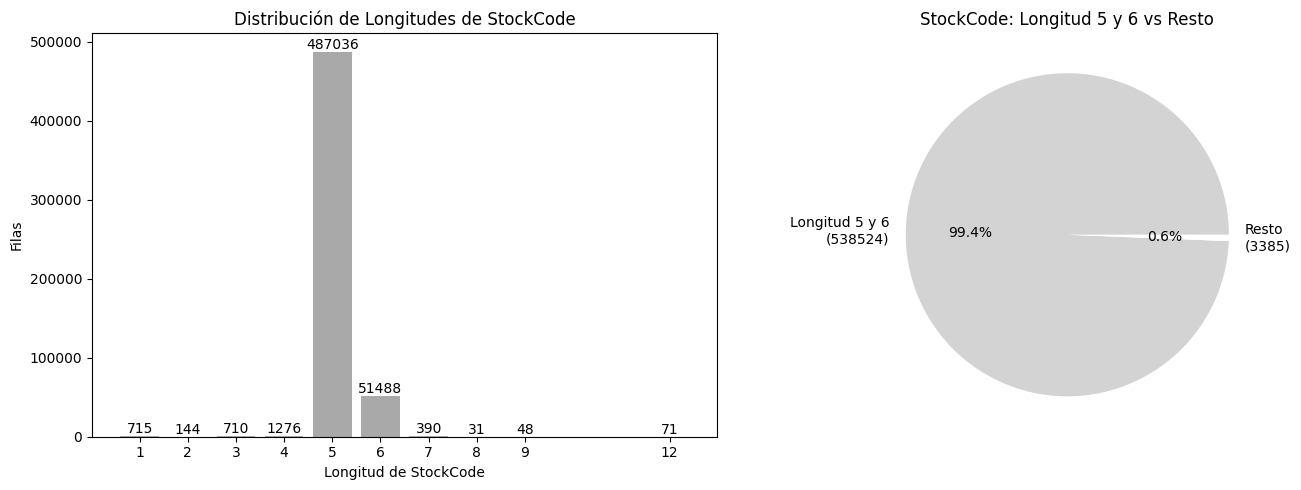

In [86]:
longitudes_stockCode = df['StockCode'].str.len().value_counts().sort_index()
print(f"\nDistribución de longitudes:\n{longitudes_stockCode}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(longitudes_stockCode.index, longitudes_stockCode.values, color='darkgray')
axes[0].set_title('Distribución de Longitudes de StockCode')
axes[0].set_xlabel('Longitud de StockCode')
axes[0].set_ylabel('Filas')
axes[0].set_xticks(longitudes_stockCode.index)
axes[0].bar_label(axes[0].containers[0], padding=0)

total_5_6 = longitudes_stockCode.get(5, 0) + longitudes_stockCode.get(6, 0)
total_resto = longitudes_stockCode.sum() - total_5_6

valores_pie = [total_5_6, total_resto]
etiquetas_pie = [f'Longitud 5 y 6\n({total_5_6})', f'Resto\n({total_resto})']

axes[1].pie(valores_pie, labels=etiquetas_pie, autopct='%1.1f%%', colors=['lightgray', 'white'])
axes[1].set_title('StockCode: Longitud 5 y 6 vs Resto')

plt.tight_layout()
plt.show()

Tenemos los siguientes datos para cada longitud de StockCode a excepción de las dos principales (5 y 6). La mayoría muestran valores para descripción que no se ajustan a una descripción propia de un producto, lo que puede ser un indicativo de datos que no pertenecen a ventas normales. Otros valores parecen ser más normales, pero representan un porcentaje muy bajo como para considerar su correcto tratamiento.

In [106]:
for n in range(1, 13):
  if n != 5 and n != 6:
    stockCode_n = df[df['StockCode'].str.len() == n]
    descripciones_stockCode_n = stockCode_n['Description'].unique()
    stock_codes_n = stockCode_n['StockCode'].unique()
    print(f"StockCodes únicos de longitud {n}:\n{stock_codes_n.tolist()[:10]}")
    print(f"\nDescripciones únicas con longitud {n}:\n{descripciones_stockCode_n.tolist()[:10]}")
    print("-----------------------------\n")

StockCodes únicos de longitud 1:
['D', 'M', 'S', 'm', 'B']

Descripciones únicas con longitud 1:
['Discount', 'Manual', 'SAMPLES', 'Adjust bad debt']
-----------------------------

StockCodes únicos de longitud 2:
['C2']

Descripciones únicas con longitud 2:
['CARRIAGE', nan]
-----------------------------

StockCodes únicos de longitud 3:
['DOT']

Descripciones únicas con longitud 3:
['DOTCOM POSTAGE', nan]
-----------------------------

StockCodes únicos de longitud 4:
['POST', 'PADS', 'CRUK']

Descripciones únicas con longitud 4:
['POSTAGE', nan, 'PADS TO MATCH ALL CUSHIONS', 'CRUK Commission']
-----------------------------

StockCodes únicos de longitud 7:
['15056BL', '15056bl', '79323GR', '79323LP']

Descripciones únicas con longitud 7:
['EDWARDIAN PARASOL BLACK', 'Unsaleable, destroyed.']
-----------------------------

StockCodes únicos de longitud 8:
['DCGS0076', 'DCGS0003', 'DCGS0070', 'DCGS0055', 'DCGS0072', 'DCGS0074', 'DCGS0069', 'DCGS0057', 'DCGSSBOY', 'DCGS0004']

Descripci

Visualizando todos los valores para longitud de StockCode 5 y 6 vemos que el formato principalmente es numérico y que las descripciones están completamente en mayúsuculas. Para valores de longitud 6 se añade una letra al final del StockCode, pero las descripciones siguen en mismo formato.

In [105]:
for n in range(5, 7):
  stockCode_n = df[df['StockCode'].str.len() == n]
  descripciones_stockCode_n = stockCode_n['Description'].unique()
  stock_codes_n = stockCode_n['StockCode'].unique()
  print(f"StockCodes únicos de longitud {n}:\n{stock_codes_n.tolist()[:10]}")
  print(f"\nDescripciones únicas con longitud {n}:\n{descripciones_stockCode_n.tolist()[:10]}")
  print("-----------------------------\n")

StockCodes únicos de longitud 5:
['71053', '22752', '21730', '22633', '22632', '84879', '22745', '22748', '22749', '22310']

Descripciones únicas con longitud 5:
['WHITE METAL LANTERN', 'SET 7 BABUSHKA NESTING BOXES', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'HAND WARMER UNION JACK', 'HAND WARMER RED POLKA DOT', 'ASSORTED COLOUR BIRD ORNAMENT', "POPPY'S PLAYHOUSE BEDROOM ", "POPPY'S PLAYHOUSE KITCHEN", 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'IVORY KNITTED MUG COSY ']
-----------------------------

StockCodes únicos de longitud 6:
['85123A', '84406B', '84029G', '84029E', '82494L', '85099C', '84997B', '84997C', '84519A', '85183B']

Descripciones únicas con longitud 6:
['WHITE HANGING HEART T-LIGHT HOLDER', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'WOODEN FRAME ANTIQUE WHITE ', 'JUMBO  BAG BAROQUE BLACK WHITE', 'RED 3 PIECE RETROSPOT CUTLERY SET', 'BLUE 3 PIECE POLKADOT CUTLERY SET', 'TOMATO CHARLIE+LOLA COASTER SET', 'CHARLIE & 

Aquí podemos observar que todos los valores de StockCode de longitud 5 cumplen el formato numérico. Para el formato de 6, todos cumplen con 5 números seguidos de una letra, pero la mayoría con una letra mayúscula. Existe una minoría que trata la letra minúscula.

In [89]:
patron_5_numeros = r'^\d{5}$'
patron_6_numeros_letra = r'^\d{5}[A-Za-z]$'
patron_6_numeros_minuscula = r'^\d{5}[a-z]$'
patron_6_numeros_mayuscula = r'^\d{5}[A-Z]$'

df_stockcode_5 = df[df['StockCode'].str.len() == 5].copy()
cumple_formato_5 = df_stockcode_5[df_stockcode_5['StockCode'].str.match(patron_5_numeros)]
cumple_formato_5_sum = len(cumple_formato_5)
total_5 = len(df_stockcode_5)
no_cumple_5 = df_stockcode_5[~df_stockcode_5['StockCode'].str.match(patron_5_numeros)]['StockCode'].unique()

df_stockcode_6 = df[df['StockCode'].str.len() == 6].copy()
cumple_formato_6 = df_stockcode_6[df_stockcode_6['StockCode'].str.match(patron_6_numeros_letra)]
cumple_formato_6_minuscula = df_stockcode_6[df_stockcode_6['StockCode'].str.match(patron_6_numeros_minuscula)]
cumple_formato_6_mayuscula = df_stockcode_6[df_stockcode_6['StockCode'].str.match(patron_6_numeros_mayuscula)]

cumple_formato_6_sum = len(cumple_formato_6)
cumple_formato_6_minuscula_sum = len(cumple_formato_6_minuscula)
cumple_formato_6_mayuscula_sum = len(cumple_formato_6_mayuscula)

total_6 = len(df_stockcode_6)
no_cumple_6 = df_stockcode_6[~df_stockcode_6['StockCode'].str.match(patron_6_numeros_letra)]['StockCode'].unique()

print(f"StockCodes de longitud 5:")
print(f"Total registros: {total_5}")
print(f"Cumplen formato (5 números): {cumple_formato_5_sum}")
print(f"No cumplen: {total_5 - cumple_formato_5_sum}")
print("---------------------------------------\n")
print(f"StockCodes de longitud 6:")
print(f"Total registros: {total_6}")
print(f"Cumplen formato (5 números + 1 letra): {cumple_formato_6_sum}")
print(f"Cumplen formato (5 números + 1 letra mayúscula): {cumple_formato_6_mayuscula_sum}")
print(f"Cumplen formato (5 números + 1 letra minúscula): {cumple_formato_6_minuscula_sum}")

StockCodes de longitud 5:
Total registros: 487036
Cumplen formato (5 números): 487036
No cumplen: 0
---------------------------------------

StockCodes de longitud 6:
Total registros: 51488
Cumplen formato (5 números + 1 letra): 51488
Cumplen formato (5 números + 1 letra mayúscula): 49608
Cumplen formato (5 números + 1 letra minúscula): 1880


A simple vista se ve que los valores con mayúscula están bien.

In [90]:
cumple_formato_6_mayuscula.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
49,536373,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 9:02,2.55,17850.0,United Kingdom
51,536373,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 9:02,2.75,17850.0,United Kingdom
60,536373,82494L,WOODEN FRAME ANTIQUE WHITE,6,12/1/2010 9:02,2.55,17850.0,United Kingdom
61,536373,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 9:02,3.39,17850.0,United Kingdom
62,536373,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 9:02,3.39,17850.0,United Kingdom
66,536375,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 9:32,2.55,17850.0,United Kingdom


Para el caso de los valores con minúscula, se pueden apreciar CustomerID nulos.

In [91]:
cumple_formato_6_minuscula.head(n=10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
5371,536862,15056p,EDWARDIAN PARASOL PINK,2,12/3/2010 11:13,12.72,NaN,United Kingdom
5438,536862,47566b,TEA TIME PARTY BUNTING,2,12/3/2010 11:13,8.47,NaN,United Kingdom
5439,536862,72349b,SET/6 PURPLE BUTTERFLY T-LIGHTS,1,12/3/2010 11:13,4.21,NaN,United Kingdom
5443,536862,84872a,TEATIME FUNKY FLOWER BACKPACK FOR 2,2,12/3/2010 11:13,11.02,NaN,United Kingdom
5445,536862,84970l,SINGLE HEART ZINC T-LIGHT HOLDER,2,12/3/2010 11:13,2.13,NaN,United Kingdom
5446,536862,84970s,HANGING HEART ZINC T-LIGHT HOLDER,5,12/3/2010 11:13,2.13,NaN,United Kingdom
5448,536862,85039a,SET/4 RED MINI ROSE CANDLE IN BOWL,1,12/3/2010 11:13,3.36,NaN,United Kingdom
5537,536864,72349b,SET/6 PURPLE BUTTERFLY T-LIGHTS,1,12/3/2010 11:27,4.21,NaN,United Kingdom
5543,536864,84970s,HANGING HEART ZINC T-LIGHT HOLDER,1,12/3/2010 11:27,2.13,NaN,United Kingdom
5548,536865,18098c,PORCELAIN BUTTERFLY OIL BURNER,7,12/3/2010 11:28,5.06,NaN,United Kingdom


Se puede comprobar que el 100% de los valores con letra minúscula en StockCode tienen CustomerID nulo, lo que puede ser un indicativo de que se tratan de datos erróneos o de un tipo de registro diferente a las ventas normales.

In [92]:
cumple_formato_6_minuscula_con_customer_nulo = cumple_formato_6_minuscula[cumple_formato_6_minuscula['CustomerID'].isnull()]
print(f"Cantidad de filas con CustomerID nulo en StockCodes de longitud 6 con formato (5 números + 1 letra minúscula): {len(cumple_formato_6_minuscula_con_customer_nulo)} | Totales: {len(cumple_formato_6_minuscula)}")

Cantidad de filas con CustomerID nulo en StockCodes de longitud 6 con formato (5 números + 1 letra minúscula): 1880 | Totales: 1880


Ahora hay que comprobar que todos los StockCodes siempre tienen la misma descripción. 

In [93]:
stock_code_descripción = df.groupby('StockCode')['Description'].nunique()
stock_codes_con_descripcion_unica = stock_code_descripción[stock_code_descripción == 1]
stock_codes_con_descripcion_multiple = stock_code_descripción[stock_code_descripción > 2]
print(f"StockCodes con descripción única: {len(stock_codes_con_descripcion_unica.index)}")
print(f"StockCodes con descripciones múltiples: {len(stock_codes_con_descripcion_multiple.index)}")

StockCodes con descripción única: 3308
StockCodes con descripciones múltiples: 133


Vemos los valores de StockCode para los que tienen múltiples descripciones. Vemos que hay casos en la que existen descripciones en minúscula que no hacen referencia al propio producto. Y otras en mayúscula que ofrecen descripciones similares con pequeñas variaciones. No tendremos en cuenta las filas con descripciones en minúsucula, ya que no son descripciones lógicas de un producto. 

In [94]:
result = df.groupby('StockCode')['Description'].apply(lambda x: x.unique())
multi_desc = result[result.apply(len) > 1]

iterator = 0

for stockcode, descriptions in multi_desc.items():
  print(f"StockCode: {stockcode}")
  print(f"Descripciones: {list(descriptions)}")
  print()
  iterator += 1
  if iterator >= 10:
    break

StockCode: 10002
Descripciones: ['INFLATABLE POLITICAL GLOBE ', nan]

StockCode: 10080
Descripciones: ['GROOVY CACTUS INFLATABLE', nan, 'check']

StockCode: 10123C
Descripciones: ['HEARTS WRAPPING TAPE ', nan]

StockCode: 10133
Descripciones: ['COLOURING PENCILS BROWN TUBE', 'damaged']

StockCode: 15030
Descripciones: ['FAN BLACK FRAME ', nan]

StockCode: 15036
Descripciones: ['ASSORTED COLOURS SILK FAN', nan]

StockCode: 15044B
Descripciones: ['BLUE PAPER PARASOL ', nan]

StockCode: 15058A
Descripciones: ['BLUE POLKADOT GARDEN PARASOL', nan, 'wet/rusty']

StockCode: 15058B
Descripciones: ['PINK POLKADOT GARDEN PARASOL', nan]

StockCode: 15058C
Descripciones: ['ICE CREAM DESIGN GARDEN PARASOL', 'wet/rusty']



Con descripciones únicas también existe algún valor en minúscula, que trataremos como inválidos.

In [95]:
one_desc = result[result.apply(len) == 1]

iterator = 0

for stockcode, descriptions in one_desc.items():
  print(f"StockCode: {stockcode}")
  print(f"Descripción: {descriptions[0]}")
  print()
  iterator += 1
  if iterator >= 10:
    break

StockCode: 10120
Descripción: DOGGY RUBBER

StockCode: 10123G
Descripción: nan

StockCode: 10124A
Descripción: SPOTS ON RED BOOKCOVER TAPE

StockCode: 10124G
Descripción: ARMY CAMO BOOKCOVER TAPE

StockCode: 10125
Descripción: MINI FUNKY DESIGN TAPES

StockCode: 10134
Descripción: nan

StockCode: 10135
Descripción: COLOURING PENCILS BROWN TUBE

StockCode: 11001
Descripción: ASSTD DESIGN RACING CAR PEN

StockCode: 15034
Descripción: PAPER POCKET TRAVELING FAN 

StockCode: 15039
Descripción: SANDALWOOD FAN



#### Análisis Quantity.

Antes hemos visto varios valores negativos en Quantity. Vamos a confirmar que existen y qué cantidad representan respecto al total de filas. No utilizaremos estas filas negativas para el análisis final, ya que no representan ventas normales, sino devoluciones, cancelaciones o datos erróneos.

In [96]:
df_quantity_negativa = df[df['Quantity'] <= 0]
cantidad_quantity_negativa = len(df_quantity_negativa)
porcentaje_quantity_negativa = (cantidad_quantity_negativa / filas_totales) * 100
print(f"Cantidad de filas con Quantity negativa: {cantidad_quantity_negativa} / {filas_totales} | Porcentaje: {porcentaje_quantity_negativa:.2f}%")

Cantidad de filas con Quantity negativa: 10624 / 541909 | Porcentaje: 1.96%


#### Análisis UnitPrice.

Al igual que con Quantity vamos a prescindir de los datos negativos o 0 que aparezcan, ya que no representan valores normales. Además no tiene sentido que el precio unitario sea negativo. Los de valor 0 los trataremos como regalos o muestras gratuitas, por lo que tampoco los consideraremos para el análisis final.

In [97]:
df_unitPrice_negativo_cero = df[df['UnitPrice'] <= 0]
cantidad_unitPrice_negativo_cero = len(df_unitPrice_negativo_cero)
porcentaje_unitPrice_negativo_cero = (cantidad_unitPrice_negativo_cero / filas_totales) * 100
print(f"Cantidad de filas con UnitPrice negativo o cero: {cantidad_unitPrice_negativo_cero} / {filas_totales} | Porcentaje: {porcentaje_unitPrice_negativo_cero:.2f}%")

Cantidad de filas con UnitPrice negativo o cero: 2517 / 541909 | Porcentaje: 0.46%


#### Análisis InvoiceDate.

Primero vamos a comprobar los rangos de fechas para que no exista ninguna errónea o que salga del rango de investigación. Vemos que está todo en orden.

In [98]:
fecha_min = df['InvoiceDate'].min()
fecha_max = df['InvoiceDate'].max()

print(f"Rango de fechas en InvoiceDate: Desde {fecha_min} hasta {fecha_max}")

Rango de fechas en InvoiceDate: Desde 1/10/2011 10:04 hasta 9/9/2011 9:52


#### Análisis CustomerID.

Sabemos de antemano que CustomerID siempre es numérico por la importación del csv. Tambié comprobamos que el 100% de los valores no nulos tienen una longitud de  7 dígitos.

In [99]:
logitudes_customId = df['CustomerID'].astype(str).str.len().value_counts().sort_index()
print(f"\nDistribución de longitudes:\n{logitudes_customId}")


Distribución de longitudes:
CustomerID
7.0    406829
Name: count, dtype: int64


#### Análisis Country.

Revisando la variable "Country" tenemos que el país con más registros es Reino Unido, seguido de Alemania y Francia muy por debajo.

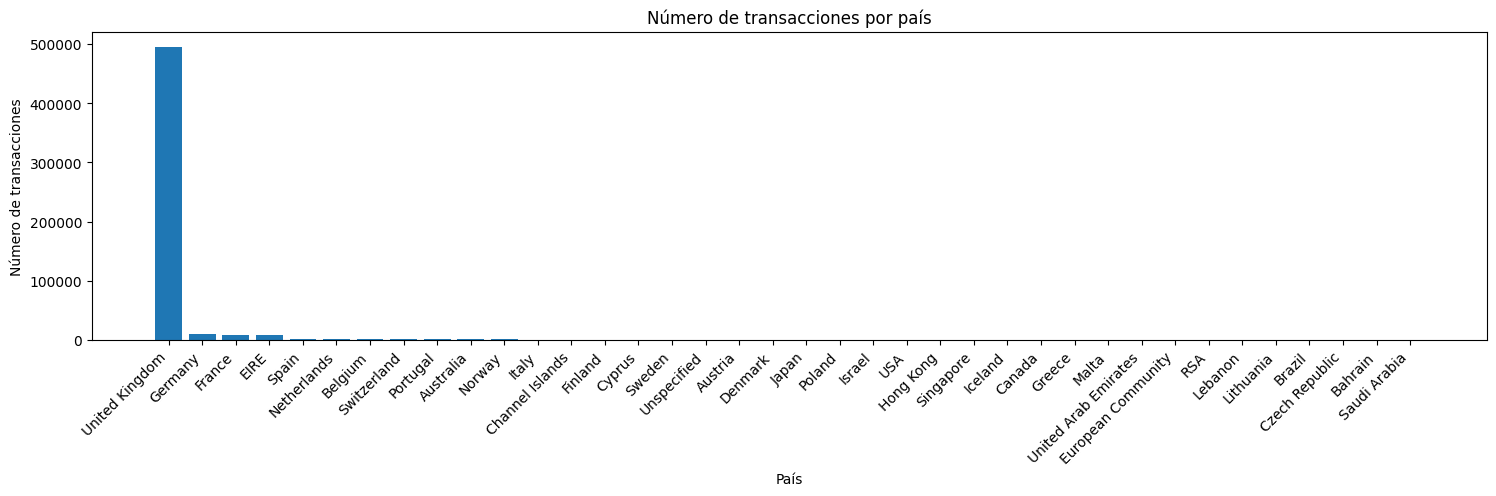

In [100]:
country_transactions = (
  df.groupby('Country')
  .size()
  .reset_index(name='Transacciones')
  .sort_values('Transacciones', ascending=False)
)

plt.figure(figsize=(18, 4))
plt.bar(x='Country', height='Transacciones', data=country_transactions)
plt.title('Número de transacciones por país') 
plt.xlabel('País')
plt.ylabel('Número de transacciones')
plt.xticks(rotation=45, ha='right')
plt.show()

#### Detección de outliers.

Vamos a tratar los outliers en las dos variables numéricas, Quantity y UnitPrice. Para ello vamos a utilizar el método del rango intercuartílico (IQR) para detectar los valores atípicos y eliminarlos del dataset. Este método se basa en calcular el rango intercuartílico, que es la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1). Los valores que se encuentran por debajo de Q1 - 1.5 * IQR o por encima de Q3 + 1.5 * IQR se consideran outliers y serán eliminados del dataset para evitar que afecten negativamente al análisis y al modelo de predicción.

##### Outliers Quantity.



In [101]:
quantity_Q1 = df["Quantity"].quantile(0.20)
quantity_Q3 = df["Quantity"].quantile(0.80)

quantity_IQR = quantity_Q3 - quantity_Q1

limite_inferior_quantity = quantity_Q1 - 1.5 * quantity_IQR
limite_superior_quantity = quantity_Q3 + 1.5 * quantity_IQR

print(f"Percentil 20 para quantity: {quantity_Q1}")
print(f"Percentil 80 para quantity: {quantity_Q3}\n")

print(f"Limite inferior para quantity: {limite_inferior_quantity}")
print(f"Limite superior para quantity: {limite_superior_quantity}\n")

outliers_quantity = df[(df["Quantity"] < limite_inferior_quantity) | (df["Quantity"] > limite_superior_quantity)]
outliers_quantity.sort_values("Quantity").head(n=5)

print(f"Cantidad de outliers en Quantity: {len(outliers_quantity)}")
print(f"Porcentaje de outliers en Quantity: {len(outliers_quantity) / len(df) * 100:.2f}%")

outliers_quantity.head(n=5).sort_values("Quantity", ascending=True)

Percentil 20 para quantity: 1.0
Percentil 80 para quantity: 12.0

Limite inferior para quantity: -15.5
Limite superior para quantity: 28.5

Cantidad de outliers en Quantity: 28985
Porcentaje de outliers en Quantity: 5.35%


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom
65,536374,21258,VICTORIAN SEWING BOX LARGE,32,12/1/2010 9:09,10.95,15100.0,United Kingdom
44,536370,22492,MINI PAINT SET VINTAGE,36,12/1/2010 8:45,0.65,12583.0,France
31,536370,10002,INFLATABLE POLITICAL GLOBE,48,12/1/2010 8:45,0.85,12583.0,France
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,12/1/2010 9:00,2.55,13748.0,United Kingdom


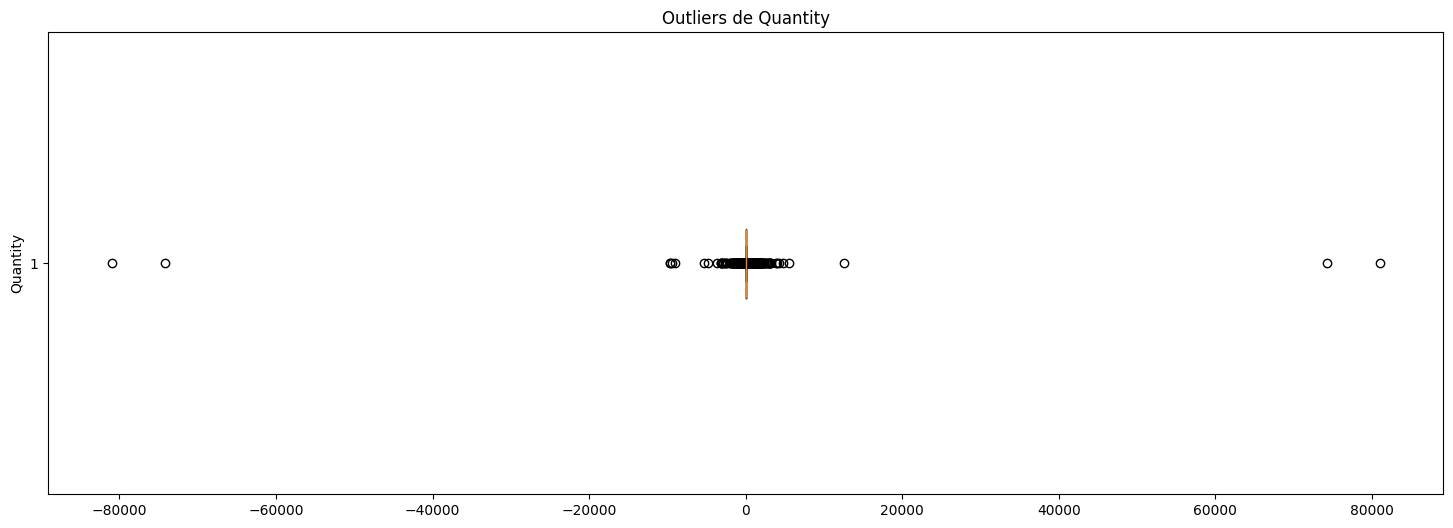

In [102]:
plt.figure(figsize=(18, 6))
plt.boxplot(df["Quantity"], vert=False)
plt.title("Outliers de Quantity")
plt.ylabel("Quantity")
plt.show()

In [103]:
unit_price_Q1 = df["UnitPrice"].quantile(0.20)
unit_price_Q3 = df["UnitPrice"].quantile(0.80)
unit_price_IQR = unit_price_Q3 - unit_price_Q1

print(f"Perceptil 20 para UnitPrice: {unit_price_Q1}")
print(f"Perceptil 80 para UnitPrice: {unit_price_Q3}\n")

unit_price_Lower = unit_price_Q1 - 1.5 * unit_price_IQR
unit_price_Upper = unit_price_Q3 + 1.5 * unit_price_IQR

print(f"Limite inferior para UnitPrice: {unit_price_Lower}")
print(f"Limite superior para UnitPrice: {unit_price_Upper}\n")

outliers_unitPrice = df[(df["UnitPrice"] < unit_price_Lower) | (df["UnitPrice"] > unit_price_Upper)]
outliers_unitPrice.sort_values("UnitPrice").head(n=5)

print(f"Cantidad de outliers en UnitPrice: {len(outliers_unitPrice)}")
print(f"Porcentaje de outliers en UnitPrice: {len(outliers_unitPrice) / len(df) * 100:.2f}%")

outliers_unitPrice.head(n=5).sort_values("UnitPrice", ascending=True)

Perceptil 20 para UnitPrice: 0.85
Perceptil 80 para UnitPrice: 4.95

Limite inferior para UnitPrice: -5.300000000000001
Limite superior para UnitPrice: 11.100000000000001

Cantidad de outliers en UnitPrice: 20141
Porcentaje de outliers en UnitPrice: 3.72%


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
152,536382,22838,3 TIER CAKE TIN RED AND CREAM,2,12/1/2010 9:45,14.95,16098.0,United Kingdom
151,536382,22839,3 TIER CAKE TIN GREEN AND CREAM,2,12/1/2010 9:45,14.95,16098.0,United Kingdom
153,536382,22783,SET 3 WICKER OVAL BASKETS W LIDS,4,12/1/2010 9:45,16.95,16098.0,United Kingdom
45,536370,POST,POSTAGE,3,12/1/2010 8:45,18.00,12583.0,France
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom


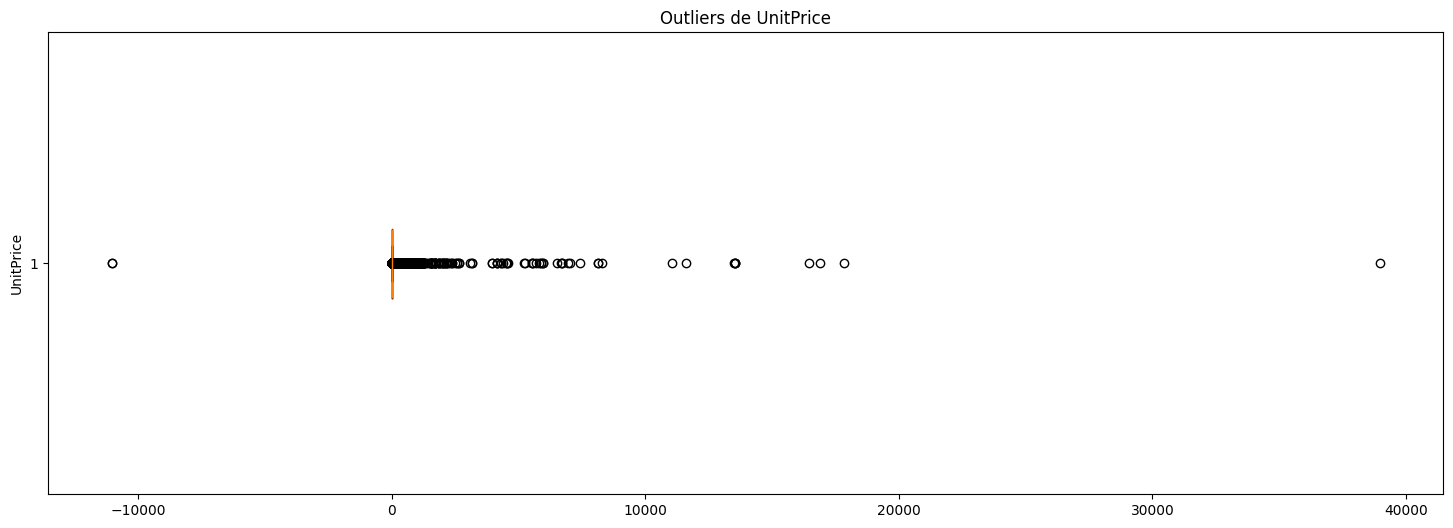

In [104]:
plt.figure(figsize=(18, 6))
plt.boxplot(df["UnitPrice"], vert=False)
plt.title("Outliers de UnitPrice")
plt.ylabel("UnitPrice")
plt.xlim()
plt.show()